## 1. Imports

In [14]:
import pandas as pd
import numpy as np
import json
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import (accuracy_score, log_loss, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

BASE = r'c:\Users\Usman\Desktop\Stock Market\Huge Stock Market'
t0 = time.time()
print('Ready!')

Ready!


## 2. Load Data

In [15]:
print('Loading ETFs...')
etfs = pd.read_csv(f'{BASE}\\ETFs_cleaned.csv')
print(f'  ETFs: {etfs.shape}')

print('Loading Stocks...')
stocks = pd.read_csv(f'{BASE}\\Stocks_cleaned.csv')
print(f'  Stocks: {stocks.shape}')

etfs['Source'] = 0
stocks['Source'] = 1
df = pd.concat([etfs, stocks], ignore_index=True)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Ticker','Date']).reset_index(drop=True)
del etfs, stocks

print(f'\nCombined: {len(df):,} rows | {df["Ticker"].nunique():,} tickers')
print(f'Date Range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Time: {time.time()-t0:.0f}s')

Loading ETFs...
  ETFs: (2562507, 7)
Loading Stocks...
  Stocks: (5085296, 7)

Combined: 7,647,803 rows | 3,693 tickers
Date Range: 1970-01-02 to 2017-11-10
Time: 36s


## 3. Quality Filter

In [16]:
ts = df.groupby('Ticker').agg(
    rows=('Date','count'), avg_vol=('Volume','mean')).reset_index()
quality = ts[(ts['rows'] >= 500) & (ts['avg_vol'] > 10000)]['Ticker'].tolist()
df = df[df['Ticker'].isin(quality)].copy()
df = df.sort_values(['Ticker','Date']).reset_index(drop=True)

print(f'Quality Tickers: {len(quality):,}')
print(f'Filtered Dataset: {len(df):,} rows')

Quality Tickers: 2,789
Filtered Dataset: 6,984,733 rows


## 4. Feature Engineering

In [17]:
print('Building features (takes ~5-8 minutes)...')
g = df.groupby('Ticker')['Close']
gv = df.groupby('Ticker')['Volume']

# Returns
for d in [1, 2, 3, 5, 10, 20]:
    df[f'Ret_{d}d'] = g.pct_change(d)

# Moving Averages & Price Ratios
for w in [5, 10, 20, 50, 100]:
    df[f'SMA_{w}'] = g.transform(lambda x: x.rolling(w).mean())
    df[f'Pr_SMA_{w}'] = df['Close'] / df[f'SMA_{w}']

for w in [5, 10, 20, 50]:
    df[f'EMA_{w}'] = g.transform(lambda x: x.ewm(span=w).mean())

# SMA Slopes
for w in [5, 10, 20, 50]:
    df[f'SMA_{w}_Slope'] = df.groupby('Ticker')[f'SMA_{w}'].pct_change(5)

# Crossovers
df['Cross_5_20'] = (df['SMA_5'] > df['SMA_20']).astype(int)
df['Cross_10_50'] = (df['SMA_10'] > df['SMA_50']).astype(int)
df['Cross_20_50'] = (df['SMA_20'] > df['SMA_50']).astype(int)
df['Cross_20_100'] = (df['SMA_20'] > df['SMA_100']).astype(int)
df['Cross_EMA_5_20'] = (df['EMA_5'] > df['EMA_20']).astype(int)
df['Cross_EMA_10_50'] = (df['EMA_10'] > df['EMA_50']).astype(int)
df['Trend_Align'] = df['Cross_5_20'] + df['Cross_10_50'] + df['Cross_20_50'] + df['Cross_20_100']

# RSI
def rsi(s, p=14):
    d = s.diff()
    gain = d.where(d > 0, 0).rolling(p).mean()
    loss = (-d.where(d < 0, 0)).rolling(p).mean()
    return 100 - 100 / (1 + gain / (loss + 1e-10))

df['RSI_7'] = df.groupby('Ticker')['Close'].transform(lambda x: rsi(x, 7))
df['RSI_14'] = df.groupby('Ticker')['Close'].transform(lambda x: rsi(x, 14))
df['RSI_21'] = df.groupby('Ticker')['Close'].transform(lambda x: rsi(x, 21))

# MACD
df['MACD'] = df['EMA_10'] - df['EMA_20']
df['MACD_Sig'] = df.groupby('Ticker')['MACD'].transform(lambda x: x.ewm(span=9).mean())
df['MACD_Hist'] = df['MACD'] - df['MACD_Sig']
df['MACD_Cross'] = (df['MACD'] > df['MACD_Sig']).astype(int)

# Volatility
for w in [5, 10, 20]:
    df[f'Vol_{w}'] = df.groupby('Ticker')['Ret_1d'].transform(lambda x: x.rolling(w).std())

# Bollinger Bands
bb_std = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(20).std())
df['BB_Width'] = (4 * bb_std) / (df['SMA_20'] + 1e-10)
df['BB_Pos'] = (df['Close'] - (df['SMA_20'] - 2 * bb_std)) / (4 * bb_std + 1e-10)

# Volume Features
df['Vol_SMA10'] = gv.transform(lambda x: x.rolling(10).mean())
df['Vol_Ratio'] = df['Volume'] / (df['Vol_SMA10'] + 1)
df['Vol_SMA20'] = gv.transform(lambda x: x.rolling(20).mean())
df['Vol_Trend'] = df['Vol_SMA10'] / (df['Vol_SMA20'] + 1)

# Price Patterns
df['Range'] = (df['High'] - df['Low']) / (df['Close'] + 1e-10)
df['Body'] = abs(df['Close'] - df['Open']) / (df['Close'] + 1e-10)
df['Upper_Wick'] = (df['High'] - df[['Open','Close']].max(axis=1)) / (df['Close'] + 1e-10)
df['Lower_Wick'] = (df[['Open','Close']].min(axis=1) - df['Low']) / (df['Close'] + 1e-10)

# Lag Features
for lag in [1, 2, 3, 5, 10]:
    df[f'RetLag_{lag}'] = df.groupby('Ticker')['Ret_1d'].shift(lag)
    df[f'VolLag_{lag}'] = df.groupby('Ticker')['Vol_Ratio'].shift(lag)

# Rolling Stats
df['Ret_Mean_10'] = df.groupby('Ticker')['Ret_1d'].transform(lambda x: x.rolling(10).mean())
df['Ret_Mean_20'] = df.groupby('Ticker')['Ret_1d'].transform(lambda x: x.rolling(20).mean())
df['Ret_Skew_20'] = df.groupby('Ticker')['Ret_1d'].transform(lambda x: x.rolling(20).skew())

# Time Features
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

print(f'Done! Shape: {df.shape}')
print(f'Time: {time.time()-t0:.0f}s')

Building features (takes ~5-8 minutes)...
Done! Shape: (6984733, 75)
Time: 176s


## 5. Target & Feature Selection

In [18]:
# TARGET: Is the 20-day SMA trending UP?
df['SMA20_Past'] = df.groupby('Ticker')['SMA_20'].shift(10)
df['Target'] = (df['SMA_20'] > df['SMA20_Past']).astype(int)

# Columns to DROP (not features)
DROP = ['Ticker','Date','Open','High','Low','Close','Volume','Source','Target',
        'SMA20_Past',
        'SMA_5','SMA_10','SMA_20','SMA_50','SMA_100',
        'EMA_5','EMA_10','EMA_20','EMA_50',
        'Vol_SMA10','Vol_SMA20']

df = df.dropna()

# Clean infinity values
FEATURES = [c for c in df.columns if c not in DROP]
for c in FEATURES:
    if df[c].dtype in ['float32','float64']:
        df[c] = df[c].replace([np.inf, -np.inf], np.nan)
        df[c] = df[c].fillna(df[c].median())
        df[c] = df[c].astype('float32')

print(f'Total Features: {len(FEATURES)}')
print(f'Dataset: {len(df):,} rows')
print(f'Target Distribution:')
print(df['Target'].value_counts())
print(f'Balance: {df["Target"].mean():.4f}')

Total Features: 56
Dataset: 6,708,622 rows
Target Distribution:
Target
1    3750464
0    2958158
Name: count, dtype: int64
Balance: 0.5591


## 6. Per-Ticker Chronological Split (70/15/15)

In [19]:
# Each ticker: first 70% = train, next 15% = val, last 15% = test
train_list, val_list, test_list = [], [], []
for ticker, grp in df.groupby('Ticker'):
    grp = grp.sort_values('Date')
    n = len(grp)
    if n < 100:
        continue
    t1 = int(n * 0.70)
    t2 = int(n * 0.85)
    train_list.append(grp.iloc[:t1])
    val_list.append(grp.iloc[t1:t2])
    test_list.append(grp.iloc[t2:])

train_df = pd.concat(train_list, ignore_index=True)
val_df = pd.concat(val_list, ignore_index=True)
test_df = pd.concat(test_list, ignore_index=True)
del train_list, val_list, test_list

# Sample training data if too large
MAX_ROWS = 1_500_000
if len(train_df) > MAX_ROWS:
    print(f'Sampling train: {MAX_ROWS:,} from {len(train_df):,}')
    train_df = train_df.sample(n=MAX_ROWS, random_state=42)

X_train = train_df[FEATURES].values
y_train = train_df['Target'].values
X_val = val_df[FEATURES].values
y_val = val_df['Target'].values
X_test = test_df[FEATURES].values
y_test = test_df['Target'].values
del train_df, val_df, test_df

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f'Train:      {X_train.shape[0]:,} ({X_train.shape[0]/(X_train.shape[0]+X_val.shape[0]+X_test.shape[0])*100:.1f}%)')
print(f'Validation: {X_val.shape[0]:,} ({X_val.shape[0]/(X_train.shape[0]+X_val.shape[0]+X_test.shape[0])*100:.1f}%)')
print(f'Test:       {X_test.shape[0]:,} ({X_test.shape[0]/(X_train.shape[0]+X_val.shape[0]+X_test.shape[0])*100:.1f}%)')

Sampling train: 1,500,000 from 4,694,784
Train:      1,500,000 (42.7%)
Validation: 1,006,075 (28.6%)
Test:       1,007,763 (28.7%)


## 7. XGBoost Training

In [20]:
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=FEATURES)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=FEATURES)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=FEATURES)

params = {
    'objective': 'binary:logistic',
    'eval_metric': ['logloss', 'error'],
    'max_depth': 10,
    'learning_rate': 0.05,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'min_child_weight': 3,
    'gamma': 0.1,
    'reg_alpha': 0.05,
    'reg_lambda': 1.0,
    'seed': 42,
    'n_jobs': -1,
    'tree_method': 'hist'
}

print(f'Parameters: {json.dumps(params, indent=2)}')
print('\nTraining...')

evals_result = {}
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=2000,
    evals=[(dtrain, 'train'), (dval, 'validation')],
    evals_result=evals_result,
    early_stopping_rounds=50,
    verbose_eval=100
)

print(f'\nBest iteration: {model.best_iteration}')
print(f'Best validation loss: {model.best_score:.6f}')

Parameters: {
  "objective": "binary:logistic",
  "eval_metric": [
    "logloss",
    "error"
  ],
  "max_depth": 10,
  "learning_rate": 0.05,
  "subsample": 0.9,
  "colsample_bytree": 0.9,
  "min_child_weight": 3,
  "gamma": 0.1,
  "reg_alpha": 0.05,
  "reg_lambda": 1.0,
  "seed": 42,
  "n_jobs": -1,
  "tree_method": "hist"
}

Training...
[0]	train-logloss:0.64534	train-error:0.44326	validation-logloss:0.65170	validation-error:0.47100
[100]	train-logloss:0.09100	train-error:0.03517	validation-logloss:0.11152	validation-error:0.04602
[200]	train-logloss:0.07266	train-error:0.02774	validation-logloss:0.10220	validation-error:0.04345
[300]	train-logloss:0.06209	train-error:0.02200	validation-logloss:0.09919	validation-error:0.04222
[400]	train-logloss:0.05438	train-error:0.01759	validation-logloss:0.09750	validation-error:0.04166
[500]	train-logloss:0.04815	train-error:0.01396	validation-logloss:0.09639	validation-error:0.04117
[600]	train-logloss:0.04292	train-error:0.01102	validation-l

## 8. Evaluation

In [21]:
def evaluate(mdl, dm, yt, name):
    yp = mdl.predict(dm)
    yc = (yp > 0.5).astype(int)
    return {
        'Set': name,
        'Acc': accuracy_score(yt, yc),
        'Loss': log_loss(yt, yp),
        'AUC': roc_auc_score(yt, yp),
        'yc': yc, 'yp': yp
    }

tr = evaluate(model, dtrain, y_train, 'Training')
va = evaluate(model, dval, y_val, 'Validation')
te = evaluate(model, dtest, y_test, 'Test')

print('=' * 70)
print('  RESULTS')
print('=' * 70)
for m in [tr, va, te]:
    print(f'  {m["Set"]:<12} -> Acc: {m["Acc"]*100:.2f}% | Loss: {m["Loss"]:.6f} | AUC: {m["AUC"]:.4f}')
print('=' * 70)

print('\nTest Set Classification Report:')
print(classification_report(y_test, te['yc'], target_names=['BEARISH', 'BULLISH']))

  RESULTS
  Training     -> Acc: 99.96% | Loss: 0.015381 | AUC: 1.0000
  Validation   -> Acc: 96.07% | Loss: 0.095331 | AUC: 0.9948
  Test         -> Acc: 96.15% | Loss: 0.093689 | AUC: 0.9949

Test Set Classification Report:
              precision    recall  f1-score   support

     BEARISH       0.95      0.95      0.95    402803
     BULLISH       0.97      0.97      0.97    604960

    accuracy                           0.96   1007763
   macro avg       0.96      0.96      0.96   1007763
weighted avg       0.96      0.96      0.96   1007763



## 9. Visualizations

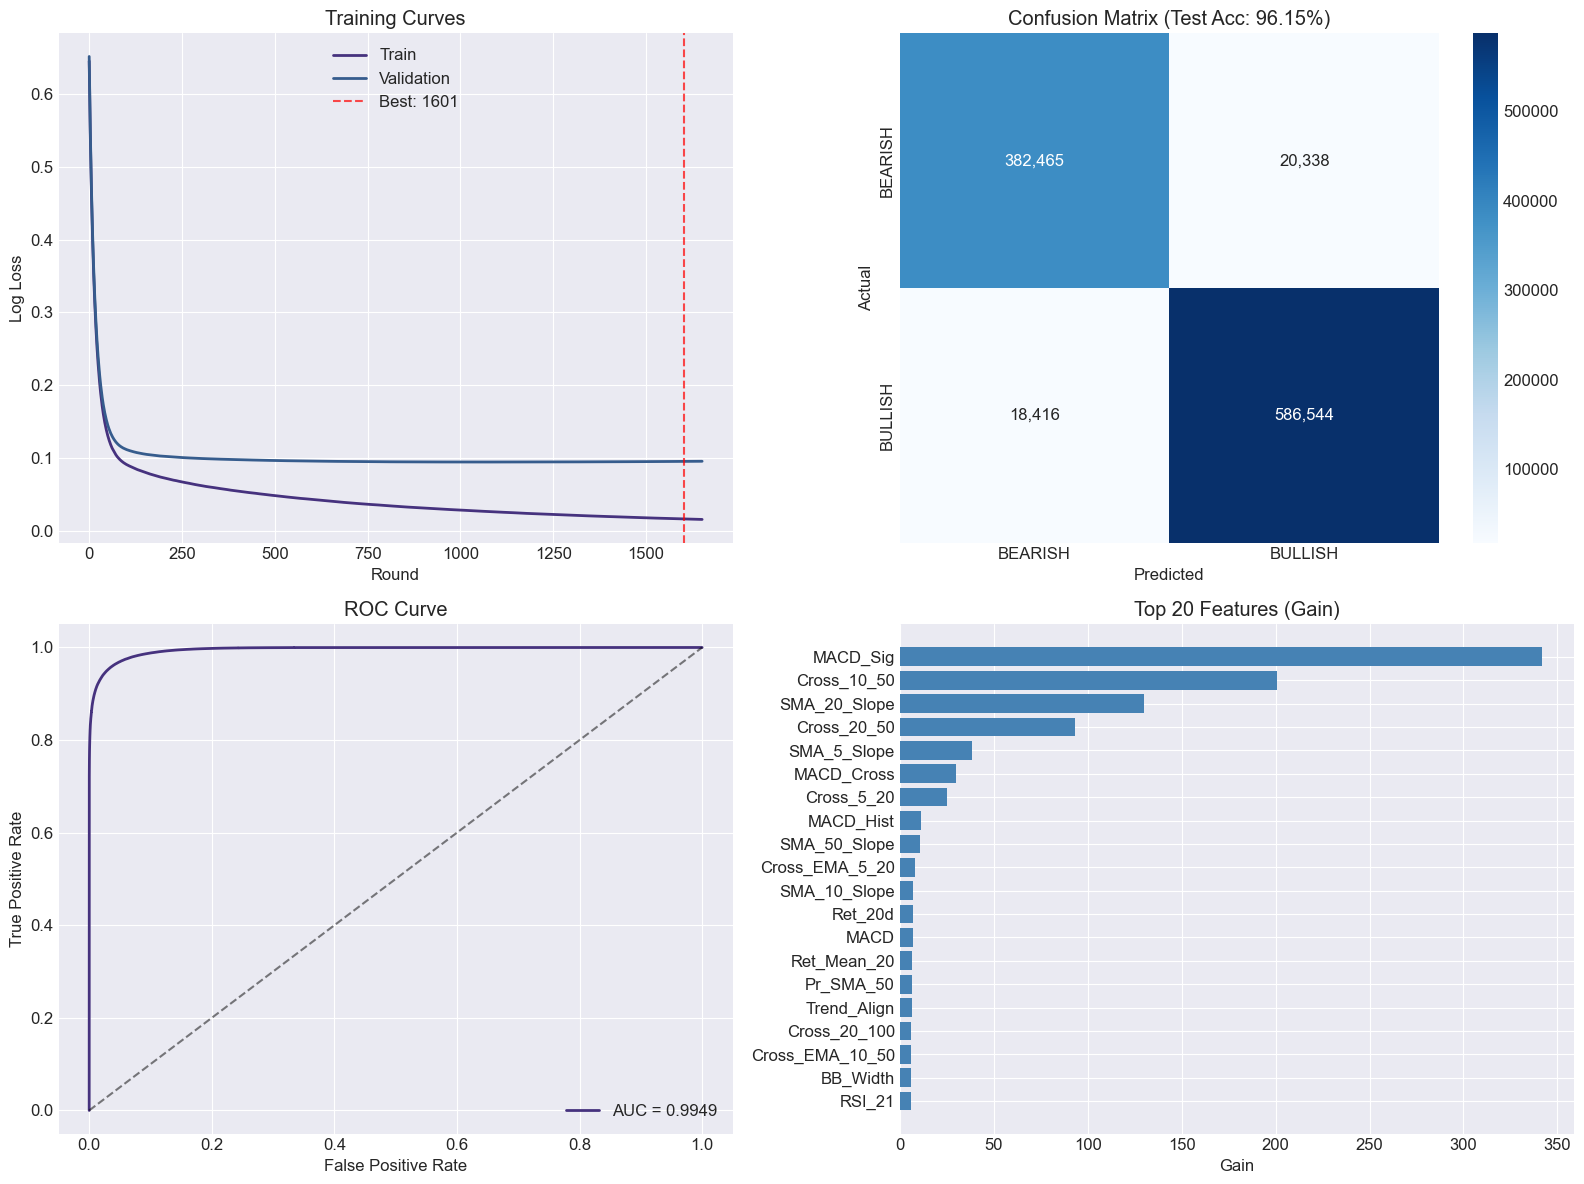

Plot saved: model_results.png


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Training curves
ax = axes[0, 0]
ax.plot(evals_result['train']['logloss'], label='Train', linewidth=2)
ax.plot(evals_result['validation']['logloss'], label='Validation', linewidth=2)
ax.axvline(model.best_iteration, color='red', linestyle='--', alpha=0.7, label=f'Best: {model.best_iteration}')
ax.set_xlabel('Round'); ax.set_ylabel('Log Loss')
ax.set_title('Training Curves'); ax.legend(); ax.grid(True)

# 2. Confusion Matrix
ax = axes[0, 1]
cm = confusion_matrix(y_test, te['yc'])
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['BEARISH','BULLISH'],
            yticklabels=['BEARISH','BULLISH'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (Test Acc: {te["Acc"]*100:.2f}%)')

# 3. ROC Curve
ax = axes[1, 0]
fpr, tpr, _ = roc_curve(y_test, te['yp'])
ax.plot(fpr, tpr, linewidth=2, label=f'AUC = {te["AUC"]:.4f}')
ax.plot([0,1], [0,1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve'); ax.legend(); ax.grid(True)

# 4. Feature Importance (Top 20)
ax = axes[1, 1]
imp = model.get_score(importance_type='gain')
imp_df = pd.DataFrame({'Feature': list(imp.keys()), 'Gain': list(imp.values())})
imp_df = imp_df.sort_values('Gain', ascending=True).tail(20)
ax.barh(imp_df['Feature'], imp_df['Gain'], color='steelblue')
ax.set_title('Top 20 Features (Gain)'); ax.set_xlabel('Gain')

plt.tight_layout()
plt.savefig(f'{BASE}\\model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: model_results.png')

## 10. Save Model, Scaler & Features

In [ ]:
# Save XGBoost model (JSON format - correct for XGBoost)
model.save_model(f'{BASE}\\xgboost_stock_model.json')

# Save StandardScaler (needed for inference on new data)
joblib.dump(scaler, f'{BASE}\\scaler.pkl')

# Save feature list
with open(f'{BASE}\\features.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)

print('=' * 70)
print('  MODEL SAVED & PIPELINE COMPLETE')
print('=' * 70)
print(f'  Features: {len(FEATURES)} | Best Round: {model.best_iteration}')
for m in [tr, va, te]:
    print(f'  {m["Set"]:<12} -> Acc: {m["Acc"]*100:.2f}% | Loss: {m["Loss"]:.6f} | AUC: {m["AUC"]:.4f}')
print(f'\n  Saved Files:')
print(f'    - xgboost_stock_model.json (XGBoost model)')
print(f'    - scaler.pkl (StandardScaler)')
print(f'    - features.json ({len(FEATURES)} features)')
print(f'    - model_results.png (plots)')
print('=' * 70)

  MODEL SAVED & PIPELINE COMPLETE
  Features: 56 | Best Round: 1601
  Training     -> Acc: 99.96% | Loss: 0.015381 | AUC: 1.0000
  Validation   -> Acc: 96.07% | Loss: 0.095331 | AUC: 0.9948
  Test         -> Acc: 96.15% | Loss: 0.093689 | AUC: 0.9949

  Saved Files:
    - xgboost_stock_model.json (XGBoost model)
    - scaler.pkl (StandardScaler)
    - features.json (56 features)
    - model_results.png (plots)


: 